### Playing with data
Aims of exploratory data anlysis, explore relationships between:
- Rainfall descriptors (event volume, is this the only rainfall characteristic?)
- Flooding outcomes ()
- Catchment descriptors
- Antecedent soil moisture conditions (mean value over catchment?, would there be a way to find mean value more specifically over the peak of the rainfall event )

In [28]:
# from jupyterthemes import get_themes
# import jupyterthemes as jt
# from jupyterthemes.stylefx import set_nb_theme

# set_nb_theme('monokai')

# jt -t monokai -N -T -kl

In [1]:
def mask_to_catchment(cube, catchment):

    catchment_proj = catchment.to_crs(epsg=27700)
    
    # Extract coordinates
    x = cube.coord('projection_x_coordinate').points
    y = cube.coord('projection_y_coordinate').points
    
    # Create 2D meshgrid of coordinates
    xx, yy = np.meshgrid(x, y)
    
    # Flatten coordinates
    points = np.vstack((xx.ravel(), yy.ravel())).T
    
    # Get catchment geometry
    catchment_geom = catchment_proj.geometry.iloc[0]
    
    # Test which grid cells are inside catchment
    mask = np.array([catchment_geom.contains(Point(pt)) for pt in points])
    
    # Reshape to grid
    mask = mask.reshape(len(y), len(x))
    return mask

In [2]:
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import os
import numpy as np
import contextily as ctx
import iris
import iris.quickplot as qplt
import iris.plot as iplt
import iris.coord_categorisation
from shapely.geometry import Point
import glob
import cartopy.crs as ccrs
import pickle 
import cftime

home_dir = "C:/Users/kv25483/OneDrive - University of Bristol/FutureFlood/Data/"
home_dir = "/scratch/hydro4/users/" # kv25483/"

# Prepare the data
Get soil data for one ensemble member over UK (from 1980 to 2080), joined into one cube

In [3]:
# Get a list of all the filenames for this EM
filenames = []
for filename in glob.glob("/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_01/*"):
    filenames.append(filename)
# Convert to an iris cubelist
cube_list = iris.load(filenames)
# Concatenate into one cube
model_cube = cube_list.concatenate_cube()  

In [ ]:
# Get a list of all the filenames for this EM
filenames = []
for filename in glob.glob("/scratch/hydro5/users/la17355/FUTURE-FLOOD/UKCP_soil_moisture/volumetric_30m/Ens_01/*"):
    filenames.append(filename)
# Convert to an iris cubelist
cube_list = iris.load(filenames)
# Concatenate into one cube
model_cube = cube_list.concatenate_cube()  

Mask the data to the Newcastle catchment

In [4]:
## Get spatial extent of catchment
catchments = gpd.read_file(home_dir + "kv25483/FutureFlood/Data/NewcastleExample/catchment_identifier/hyd_areas_GB_with_subcatchments.shp")
newcastle = catchments[catchments['HA_NUM'] == "23"]

In [5]:
mask = mask_to_catchment(model_cube, newcastle)

Get the dates in human readable (and plottable) format

In [6]:
iris.FUTURE.date_microseconds = True
# Get a list of dates covered by the soil moisture data
def create_datetime_dates_from_cube(cube):
    time_coord = cube.coord('time')
    dates = time_coord.units.num2date(time_coord.points)
    time_numeric = cube.coord('time').points
    dates = pd.to_datetime("1970-01-01") + pd.to_timedelta(time_numeric, unit='h')
    return dates 

dates = create_datetime_dates_from_cube(model_cube)
print(dates[:4])

years = dates.year
print(years[:4])

DatetimeIndex(['1980-10-05 12:00:00', '1980-10-06 12:00:00',
               '1980-10-07 12:00:00', '1980-10-08 12:00:00'],
              dtype='datetime64[ns]', freq=None)
Index([1980, 1980, 1980, 1980], dtype='int32')


## Find the mean daily/monthly soil moisture over time in Newcastle catchment

Find mean moisture over catchment (masking on the fly)

In [7]:
# The np.where condition means: Where grid cells are inside Newcastle → keep real soil moisture values
#                               Where grid cells outside Newcastle → replace with np.nan
# This creates (on the fly) a masked 3D array with shape: (nt, ny, nx), which isn't saved but is used in the np.nanmean() calculation
# np.nanmean() then calculates the mean value across ny, nx dimensions (i.e. across the catchment), ignoring any np.nan values 
# To produce an output of shape (,nt).
if os.path.exists('../Data/catchment_daily_mean.pickle'):
    print("File already exists, reading in")
    file = open('../Data/catchment_daily_mean.pickle','rb')
    catchment_daily_mean = pickle.load(file)
else:
    catchment_daily_mean = np.nanmean(np.where(mask, model_cube.data, np.nan), axis=(1, 2))
    with open('../Data/catchment_daily_mean.pickle', 'wb') as handle:
        pickle.dump(catchment_daily_mean, handle, protocol=pickle.HIGHEST_PROTOCOL)

File already exists, reading in


Convert to dataframe

In [8]:
daily_means = pd.DataFrame({'dates':dates, 'daily_means':catchment_daily_mean, 'year':years})

Convert to monthly mean (and recreate daily mean, as setting the index to 'dates' messes it up)

In [87]:
daily_means = daily_means.set_index('dates')
monthly_means = daily_means['daily_means'].resample('MS').mean()
monthly_means = (daily_means['daily_means'].resample('MS').mean().reset_index())
monthly_means.rename(columns={'daily_means':'monthly_means'}, inplace=True)
monthly_means['year'] = monthly_means['dates'].dt.year
monthly_means['month'] = monthly_means['dates'].dt.month
daily_means = pd.DataFrame({'dates':dates, 'daily_means':catchment_daily_mean, 'year':years})

## Get rainfall events

In [27]:
# os.listdir("/scratch/hydro4/users/ld14116/5km_grid/Rainfall_events/Events_duration_ensemble_monthly_threshold_varying_95th")
events =pd.read_csv("/scratch/hydro4/users/ld14116/5km_grid/Rainfall_events/Events_duration_ensemble_monthly_threshold_consistent/NorthEastEngland_Ens_04_2020-2040_full_events.csv")

Create a date object, NB this is in a 360 day calendar so doesn't work with plotting functionality

In [28]:
events['start_date'] = [cftime.Datetime360Day(y, m, d, h)
                for y, m, d, h in zip(events['start_year'], events['start_month'], events['start_day'], events['start_hour'])]
events['stop_date'] = [cftime.Datetime360Day(y, m, d, h)
                for y, m, d, h in zip(events['stop_year'], events['stop_month'], events['stop_day'], events['stop_hour'])]

## Plot daily soil moisture over time
For one year

In [98]:
def plot_soil_moisture_one_year_with_seasonal_boundaries(year, ax, one_plot, dataframe, col):
    one_year_soil_moisture = dataframe[dataframe['year']==year]
    one_year_events = events[events['start_year']==year].copy()
    
    ax.plot(one_year_soil_moisture['dates'], one_year_soil_moisture[col])
    
    # Axis labels
    if  ax.get_subplotspec().is_first_col() :
        ax.set_ylabel("Catchment Mean \n Soil Moisture")
    else:
        ax.set_ylabel("")

    if  ax.get_subplotspec().is_last_row() :
        ax.set_xlabel("Model Time")
    else:
        ax.set_xlabel("")
    
    # Title
    ax.set_title(year)
    
    #ax.xaxis.set_major_locator(mdates.MonthLocator())
    # Format tick labels to show month only
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Jan, Feb, etc.
    plt.setp(ax.get_xticklabels(), rotation=0)
    if one_plot:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    
    # # Define season boundaries
    winter_start = pd.Timestamp(f"{year}-01-01")
    spring_start = pd.Timestamp(f"{year}-03-01")
    summer_start = pd.Timestamp(f"{year}-06-01")
    autumn_start = pd.Timestamp(f"{year}-09-01")
    winter2_start = pd.Timestamp(f"{year}-12-01")
    next_year_start = pd.Timestamp(f"{year+1}-01-01")

    # # Add shaded regions
    ax.axvspan(winter_start, spring_start, color='lightblue', alpha=0.2)
    ax.axvspan(spring_start, summer_start, color='lightgreen', alpha=0.2)
    ax.axvspan(summer_start, autumn_start, color='khaki', alpha=0.2)
    ax.axvspan(autumn_start, winter2_start, color='navajowhite', alpha=0.2)
    ax.axvspan(winter2_start, next_year_start, color='lightblue', alpha=0.2)

    event_dates= one_year_events['start_date']
    if len(event_dates) >0:
        for event in event_dates:
            try:
                ax.axvline(event, color = 'red', linestyle='--');
            except:
                print("date which breaks rules")

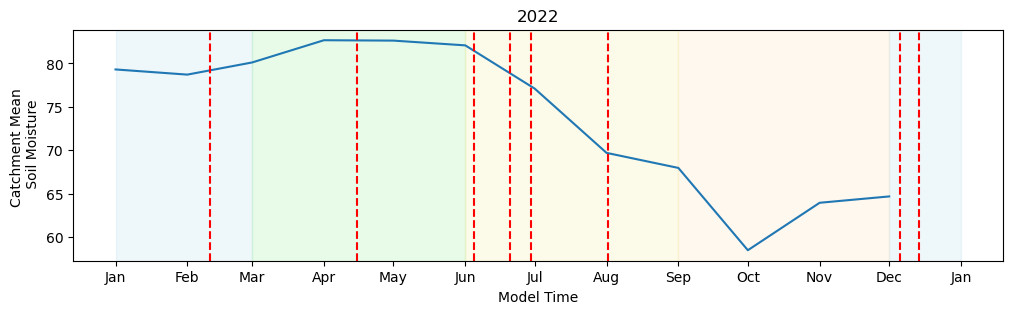

In [99]:
fig,ax=plt.subplots(figsize=(12,3))
plot_soil_moisture_one_year_with_seasonal_boundaries(year = 2022, ax = ax, one_plot=True,
                                                    dataframe=monthly_means, col='monthly_means')

For multiple years

date which breaks rules


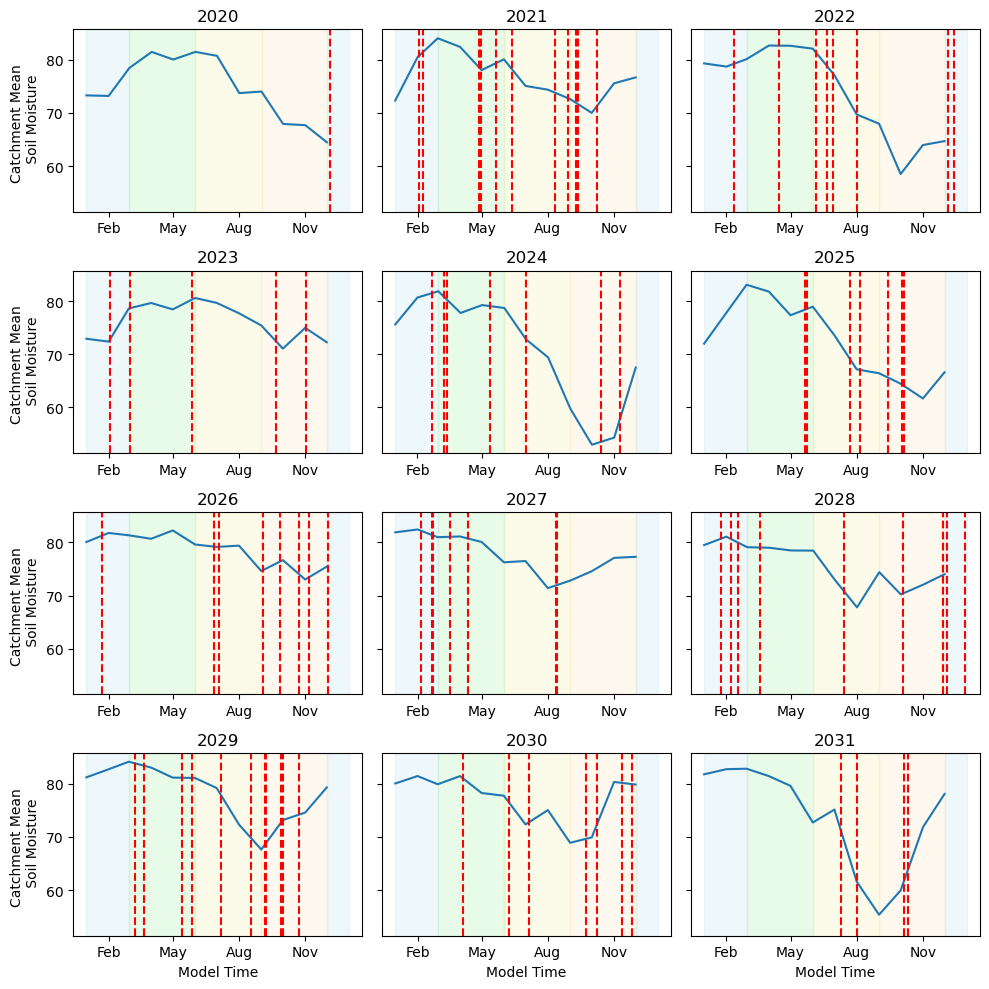

In [100]:
fig,axs=plt.subplots(ncols=3, nrows=4, figsize=(10,10), sharey=True)
axs=axs.flatten()
for ax_num, year in enumerate(range(2020,2032)):
    plot_soil_moisture_one_year_with_seasonal_boundaries(year = year, ax = axs[ax_num], one_plot=False,
                                                        dataframe=monthly_means, col = 'monthly_means')

fig.tight_layout()

## Find catchment mean soil moisture over different time periods
#### Add extra time variables

In [28]:
iris.coord_categorisation.add_season(model_cube, 'time', name='clim_season')
iris.coord_categorisation.add_month(model_cube, 'time', name='month')
iris.coord_categorisation.add_year(model_cube, 'time', name='year')
iris.coord_categorisation.add_season_year(model_cube, 'time', name='season_year')

#### Aggregate by extra time variables

In [70]:
seasonal_mean = model_cube.aggregated_by(['clim_season', 'season_year'], iris.analysis.MEAN)
monthly_mean = model_cube.aggregated_by(['month', 'year'], iris.analysis.MEAN)

### Find catchment mean over extra time variables (e.g., month, season, year)
This ends up with slightly odd looking dates, i.e. for month they are not always the first day of the month. This is because of the way the create_datetimes_dates_from_cube function is working (using 'h' since the origin), and because months aren't all consistent lengths [I think]. But for current purposes I think this is fine

In [71]:
# Monthly
catchment_monthly_mean = np.nanmean(np.where(mask, monthly_mean.data, np.nan), axis=(1, 2))
catchment_monthly_dates = create_datetime_dates_from_cube(monthly_mean)
# Seasonal
catchment_seasonal_mean = np.nanmean(np.where(mask, seasonal_mean.data, np.nan), axis=(1, 2))
catchment_seasonal_dates = create_datetime_dates_from_cube(seasonal_mean)

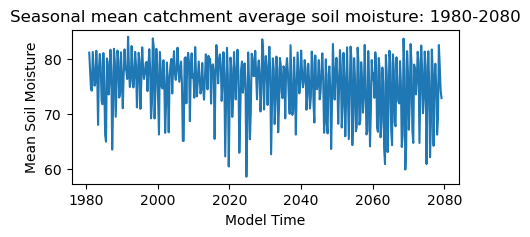

In [72]:
plt.figure(figsize=(5,2))
plt.plot(catchment_seasonal_dates, catchment_seasonal_mean)
plt.xlabel("Model Time")
plt.ylabel("Mean Soil Moisture")
plt.title("Seasonal mean catchment average soil moisture: 1980-2080")
plt.show()

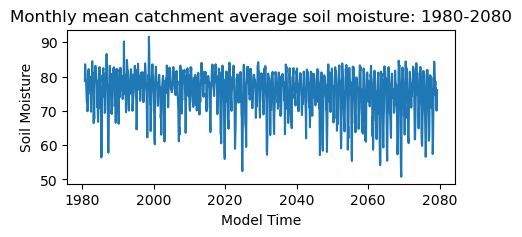

In [73]:
plt.figure(figsize=(5,2))
plt.plot(catchment_monthly_dates, catchment_monthly_mean)
plt.xlabel("Model Time")
plt.ylabel("Soil Moisture")
plt.title("Monthly mean catchment average soil moisture: 1980-2080")
plt.show()

## Relate soil moisture to other variables